# MS3: EDA, Baseline Modeling, and Pipeline Development

**Canvas Project #150**

**Project:** Hyperbolic Embeddings for Hierarchical Style Representation

**Group Members:** Peter Flo, Luca Grossmann, Valerie Wang

**COMPSCI 2090B — Spring 2026**

 ## 1. Introduction

Artistic styles are hierarchical, broad traditions branch into substyles based on lineage or aesthetics.


**Hypothesis**: Hyperbolic embedding spaces might outperform Euclidian embedding spaces for representing tree-like branching structure.

**Intuition for why geometry might matter:** In Euclidean space, the volume of a ball at radius $r$ grows polynomially in $r$, whereas in hyperbolic space (the Poincaré ball) it grows exponentially. This better matches how a tree's node count grows with depth. In addition, the Poincaré ball provides a geometric intuition for why a tree of art styles might fit better inside a Poincaré ball, where more space at the boundaries for branches, leaves.




## 2. EDA Review:

After our extended EDA, the two standout realizations were 
-  Severe class imbalance among artistic genre labels: e.g., many ‘Impressionism’, few ‘Cubism’
-  Some freedom or arbitrariness in defining ground-truth tree hierarchy

For a deeper dive on this with visuals, refer to `ms2_data_wrangling.ipynb`

**Refined our problem statement**
- *Do Poincaré ball embeddings trained on frozen CLIP features better recover the ground-truth tree structure (as measured by tree distortion and hierarchical clustering metrics) compared to Euclidean embeddings of the same dimensionality?*
 - *How might different tree structures affect performance?*


Our baseline model is an impementation of a Euclidean and Hyperbolic classifier. Our primary goal for this baseline was to isolate all variables other than geometry to provide a fair arena for comparison. As a result, we have not yet implemented class rebalancing or tree exploration due to them not affecting geometry independence. We will explore them as we look to further develop our model/project. 


### 3. Baseline Model

We train two prototype classifiers on frozen CLIP ViT-B/16 features. Our baseline has one classifier in euclidian geometry, and the other on a Poincaré ball. By using an identical MLP architecture for both implementations, geometry is isolated as the independent variable. This baseline model fully encapsulates a basic implementation of our project statement. 

#### a. WikiArt --> Preprocessing

To preprocess the data for our baseline model, we had to prepare the data for the CLIP ViT-B/16 image encoder which we are going to keep frozen during training.

To do this, we take images in WikiArt:

1. **Resize** the shorter side to 224.
2. **CenterCrop** to 224×224.
3. **Convert to RGB** 
4. **ToTensor** — `PIL` → `float32` tensor `(3, 224, 224)`.
5. **Normalize** with CLIP's mean/std:
   - mean = `(0.48145466, 0.4578275, 0.40821073)`
   - std  = `(0.26862954, 0.26130258, 0.27577711)`

The data is already partitioned in a 70/30 train/val split. We are currently using all classes in the data, but we might explore holding certain labels in the future. Reintroducing classes after the fact you illuminate how well the model can generalize. 

#### b. CLIP ViT-B/16 Encoder

To extract semantic features from the data, we pass the images through CLIP ViT-B/16. The outputted data is much lower dimensional and more easily parsed. 

To avoid passing the data through Clip on every forward pass, we did one pass through of our entire dataset and saved the output. 

``` Python
    model, _, preprocess = open_clip.create_model_and_transforms(
        "ViT-B-16", pretrained="openai", device=device)
    model.eval()

    loader = DataLoader(WikiArtDataset(paths, preprocess),
                        batch_size=128, num_workers=8, shuffle=False)

    chunks = []
    t0 = time.time()
    with torch.no_grad():
        for batch in tqdm(loader):
            chunks.append(model.encode_image(batch.to(device)).cpu().numpy())
    features = np.concatenate(chunks).astype(np.float16)

``` 

To run this code and get the embeddings locally:

`python extract_clip_features.py`

#### c. Shared MLP Head

To ensure fair comparison, both geometries will share an MLP. Here we pick the final embedding dimension of the data. The following code for sections c,d are located in `models.py`. 

```python 
class MLP(nn.Module):
    def __init__(self, d_in: int = 512, d_hidden: int = 256, d_out: int = 8, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, d_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, d_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, d_out),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

```

#### d. Geometry Specific Hats

**Euclidian Hat**: Simple pass through from the MLP, already in Euclidian space. 

```python 
class EuclideanHead(nn.Module):
    def __init__(self, d_in: int = 512, d_hidden: int = 256, d_out: int = 8, dropout: float = 0.1):
        super().__init__()
        self.mlp = MLP(d_in, d_hidden, d_out, dropout)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.mlp(z)

```


**Hyperbolic Hat**: map features into a $d$-dim Poincaré ball

To implement the Hyperbolic Hat, we first pass the data through the MLP.

After a couple of careful normalization steps (to keep points away from
$0$ and the boundary $1/\sqrt{c}$) we exponentiate them via the
exponential map at the origin:

$$
\exp_0^c(u) \;=\; \tanh\!\bigl(\sqrt{c}\,\|u\|\bigr)\,
                  \frac{u}{\sqrt{c}\,\|u\|}.
$$


```python 
class PoincareHead(nn.Module):
    MAX_TANGENT_NORM = 15.0  # prevents tanh saturation at the ball boundary

    def __init__(
        self,
        d_in: int = 512,
        d_hidden: int = 256,
        d_out: int = 8,
        dropout: float = 0.1,
        curvature: float = 1.0,
    ):
        super().__init__()
        self.mlp = MLP(d_in, d_hidden, d_out, dropout)
        self.curvature = curvature

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        u = self.mlp(z)
        norm = u.norm(dim=-1, keepdim=True).clamp_min(1e-12)
        scale = torch.clamp(norm, max=self.MAX_TANGENT_NORM) / norm
        u = u * scale
        return poincare_expmap0(u, curvature=self.curvature)

```

#### e. ClassifierLayer

We cannot use traiditonal Neural Net classification that we have seen in class because linear layers do not work in Poincare space: There is no mechanism to keep points within the sphere. 

Prototype classifiers is a natural alternative. 


Learn 27 prototype points `p_k ∈ d_dimensional space` (one per style). Classify with:

$$ p(y=k \mid x) = \frac{\exp(-d_(v, p_k))}{\sum_{k'} \exp(-d_(v, p_{k'}))} $$

For any valid distance metric d: 

**Euclidian**
  $$
  d(x, y) \;=\; \|x - y\|_2 \;=\; \sqrt{\textstyle\sum_i (x_i - y_i)^2}.
  $$

**Hyperbolic**
  $$
  d^c(x, y)
  \;=\;
  \frac{1}{\sqrt{c}}\,
  \operatorname{arcosh}\!\left(
    1 + \frac{2\,c\,\|x - y\|^2}
            {(1 - c\,\|x\|^2)(1 - c\,\|y\|^2)}
  \right).
  $$


We will learn prototype points and network parameters simultaneously to maximize log likelihood, which in practice will lower Cross Entropy Error. 

```python

class ClassifierLayer(nn.Module):

    def __init__(
        self,
        num_classes: int = 27,
        dim: int = 8,
        geometry: Literal["euclidean", "hyperbolic"] = "euclidean",
        curvature: float = 1.0,
        init_scale: float = 1e-3,
    ):
        super().__init__()
        self.geometry = geometry
        self.curvature = curvature
        init = torch.randn(num_classes, dim) * init_scale
        if geometry == "euclidean":
            self.prototypes = nn.Parameter(init)
        elif geometry == "hyperbolic":
            init = project_to_poincare_ball(init, curvature=curvature)
            if geoopt is None:
                self.prototypes = nn.Parameter(init)
            else:
                ball = geoopt.PoincareBall(c=curvature)
                self.prototypes = geoopt.ManifoldParameter(init, manifold=ball)
        else:
            raise ValueError(f"Unsupported geometry: {geometry}")

    def forward(self, v: torch.Tensor) -> torch.Tensor:
        # v: (B, d); prototypes: (K, d)
        if self.geometry == "euclidean":
            dists = torch.cdist(v, self.prototypes)  # (B, K)
        else:
            v_exp = v.unsqueeze(1)  # (B, 1, d)
            p_exp = self.prototypes.unsqueeze(0)  # (1, K, d)
            dists = poincare_distance(v_exp, p_exp, curvature=self.curvature)
        return -dists  # logits

```

**Parameter Choices**

For initial hparam choices, we picked things that looked reasonable:
- c (curvature) = 1 
- d (embedding dim) = 8
- lr = 1e-3
- lr_proto = 1e-2


 So far we have done minimal hparam tuning, but plan to set up a grid search due to how fast the model trains. 



## 4. Results Interpretation and Analysis:


### Euclidean vs. Hyperbolic Validation Results

We evaluated both models on the **24,421-image validation split**. Both models start from frozen CLIP ViT-B/16 features and learn an 8-dimensional embedding head. The Euclidean model is the baseline, while the hyperbolic model swaps in a Poincare-ball head with Riemannian prototype optimization.

#### How These Results Were Produced

- Training entry points: `scripts/train.py`
- Evaluation entry point: `scripts/eval.py`
- Main summary files: `data/runs/euclidean_d8_e10/eval_val_section2/metrics.json` and `data/runs/hyperbolic_d8_e10/eval_val_section2/metrics.json`
- Plot sources used below: `tree_distortion_pairs.csv`, `per_class_accuracy.csv`, and `frechet_interpolation_trials.csv`

To reproduce these runs locally:

```bash
python - <<'PYTRAIN'
from pathlib import Path
from scripts.train import train_euclidean, train_hyperbolic

train_euclidean(dim=8, epochs=10, batch_size=4096, run_dir=Path('data/runs/euclidean_d8_e10'), device='cpu')
train_hyperbolic(dim=8, epochs=10, batch_size=4096, run_dir=Path('data/runs/hyperbolic_d8_e10'), device='cpu')
PYTRAIN

python scripts/eval.py --ckpt data/runs/euclidean_d8_e10/ckpt.pt --split val --batch-size 4096 --device cpu --output-dir data/runs/euclidean_d8_e10/eval_val_section2
python scripts/eval.py --ckpt data/runs/hyperbolic_d8_e10/ckpt.pt --split val --batch-size 4096 --device cpu --output-dir data/runs/hyperbolic_d8_e10/eval_val_section2
```

Note: `data/` is gitignored, so the CSVs and raw evaluation artifacts are generated locally.

#### Metric Guide

These metrics mix standard classification scores with project-specific hierarchy diagnostics. The short version is: some metrics test **basic style prediction**, some test **global tree recovery**, and some test **local neighborhood structure**.

| Metric | Intuitive description | Why we use it here | Further reading |
|---|---|---|---|
| Top-1 / Top-5 accuracy | How often the correct style is the model's first guess, or at least appears in its top 5 guesses. | This is the basic sanity check that the embedding separates styles at all. | [Accuracy and precision](https://en.wikipedia.org/wiki/Accuracy_and_precision) |
| Balanced accuracy | Average per-class recall, so rare styles count more fairly instead of being overwhelmed by large classes. | WikiArt style labels are imbalanced, so this is more informative than raw accuracy alone. | [Sensitivity and specificity](https://en.wikipedia.org/wiki/Sensitivity_and_specificity), [Multiclass classification](https://en.wikipedia.org/wiki/Multiclass_classification) |
| Class-center/tree Spearman | Rank correlation between learned inter-style distances and the hand-built tree distances. Higher means the ordering of style relationships is more tree-like. | This asks whether the embedding preserves the hierarchy globally, not just whether it classifies images well. | [Spearman's rank correlation coefficient](https://en.wikipedia.org/wiki/Spearman%27s_rank_correlation_coefficient) |
| Tree distortion | Measures how much the embedding stretches or compresses tree distances. Lower is better, and values closer to 1 mean less distortion. | This is the most direct geometry-based test of whether the learned space matches the art-style tree. | [Distortion (mathematics)](https://en.wikipedia.org/wiki/Distortion_%28mathematics%29) |
| Dendrogram cluster F1 | Compares clusters recovered from agglomerative clustering with the hand-built hierarchy. Higher means the recovered tree looks more like the reference tree. | This checks whether the learned embedding supports the same branching structure as the art-history hierarchy. | [Hierarchical clustering](https://en.wikipedia.org/wiki/Hierarchical_clustering), [Dendrogram](https://en.wikipedia.org/wiki/Dendrogram), [F-score](https://en.wikipedia.org/wiki/F-score) |
| Sibling / cousin recall@k | Among the nearest neighbors of an image, how often we recover images from the same local branch of the tree. Higher is better. | This tests local neighborhood quality, which is where hyperbolic geometry may help even if global metrics lag behind. | [Nearest neighbor search](https://en.wikipedia.org/wiki/Nearest_neighbor_search), [Precision and recall](https://en.wikipedia.org/wiki/Precision_and_recall) |
| Frechet mean stability | Checks whether averaging several same-style embeddings still lands near that style and stays away from competing styles. | This evaluates interpolation stability for fine-grained families like Cubism. | [Frechet mean](https://en.wikipedia.org/wiki/Fr%C3%A9chet_mean) |

#### Metric Summary

| Metric | Euclidean d=8 | Hyperbolic d=8 | Better |
|---|---:|---:|---|
| Top-1 accuracy | 54.3% | 47.3% | Euclidean |
| Top-5 accuracy | 92.4% | 89.8% | Euclidean |
| Balanced accuracy | 37.2% | 30.0% | Euclidean |
| Class-center/tree Spearman | 0.292 | 0.189 | Euclidean |
| Average tree distortion | 1.782 | 1.856 | Euclidean |
| Worst-case tree distortion | 5.339 | 6.599 | Euclidean |
| Dendrogram cluster F1 | 0.051 | 0.000 | Euclidean |
| Sibling recall@5 | 0.199 | 0.219 | Hyperbolic |
| Sibling recall@10 | 0.281 | 0.328 | Hyperbolic |
| Cousin recall@5 | 0.287 | 0.315 | Hyperbolic |
| Cousin recall@10 | 0.365 | 0.405 | Hyperbolic |
| Cubism Frechet-mean nearest-prototype accuracy | 0.91 | 0.39 | Euclidean |

#### Narrative Summary

The story of this validation run is fairly consistent. The **Euclidean baseline is stronger on the global metrics**, including classification, class-center/tree agreement, tree distortion, dendrogram recovery, and Frechet interpolation stability. The **hyperbolic model already looks more promising on local retrieval**, where it achieves better sibling and cousin recall at both `k=5` and `k=10`. The figures below follow that story one question at a time.


#### A Narrative Read Of The Validation Run

Rather than treating the evaluation as a single scorecard, the next four figures walk through the same questions listed in the pipeline plan:

1. Is one model stronger overall on the held-out validation set?
2. Does one geometry better recover the hand-built art-style tree?
3. Are the gains and losses broad, or are they concentrated in a few styles?
4. Is interpolation stable for a fine-grained family like Cubism?


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

repo = Path.cwd()
if not (repo / 'data').exists():
    repo = repo.parent
if not (repo / 'data').exists():
    repo = Path('/Users/peterflo/Desktop/hyperbolic')

runs = {
    'Euclidean': repo / 'data/runs/euclidean_d8_e10/eval_val_section2',
    'Hyperbolic': repo / 'data/runs/hyperbolic_d8_e10/eval_val_section2',
}
metrics = {name: json.loads((path / 'metrics.json').read_text()) for name, path in runs.items()}
colors = {'Euclidean': '#1f77b4', 'Hyperbolic': '#d62728'}
sns.set_theme(style='whitegrid', context='talk')


#### Question 1. Is One Model Stronger Overall?

Source: `metrics.json`. The first plot separates the broad validation metrics from the local retrieval metrics, which keeps the main comparison readable and makes the Euclidean-versus-hyperbolic tradeoff visible immediately.

Euclidean is stronger on the overall validation metrics, especially balanced accuracy, tree correlation, dendrogram agreement, and Frechet stability. Hyperbolic only leads on sibling and cousin retrieval, so its current advantage looks local rather than end-to-end.


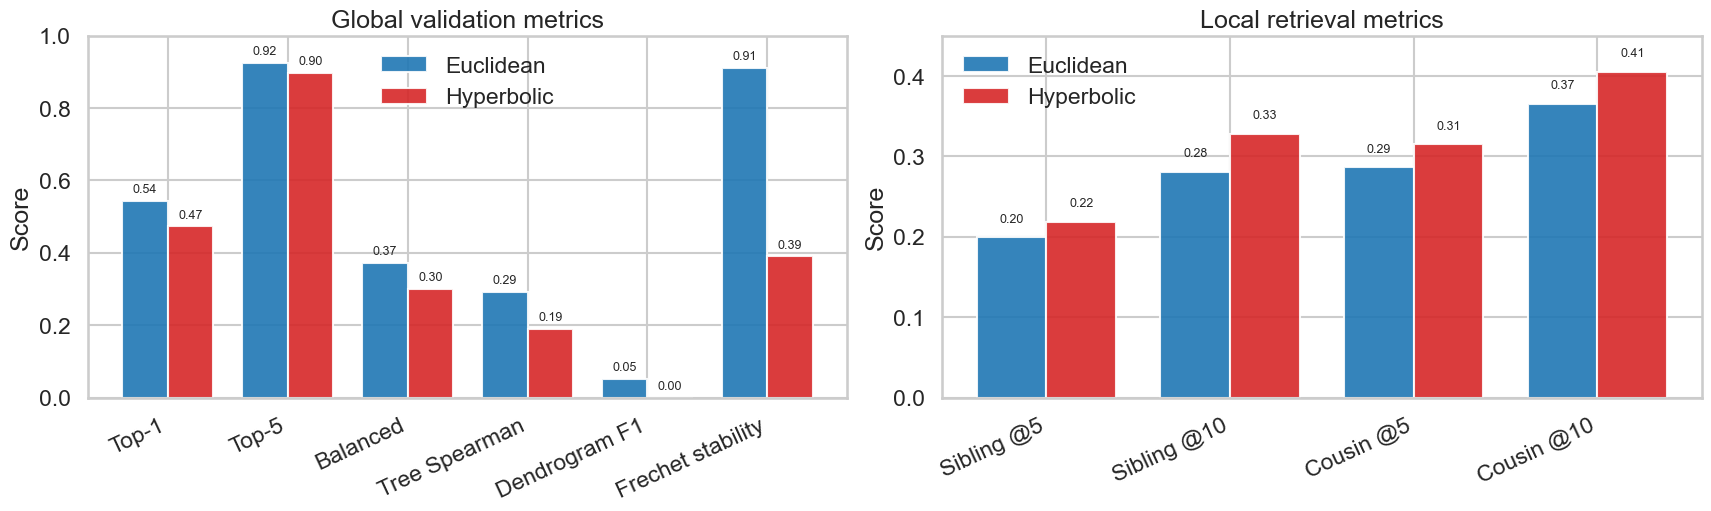

In [2]:
summary_metrics = [
    ('Top-1', 'top1_accuracy'),
    ('Top-5', 'top5_accuracy'),
    ('Balanced', 'balanced_accuracy'),
    ('Tree Spearman', 'class_center_tree_spearman'),
    ('Dendrogram F1', 'dendrogram_cluster_f1'),
    ('Frechet stability', 'frechet_nearest_prototype_accuracy'),
]
retrieval_metrics = [
    ('Sibling @5', 'knn_siblings_recall_at_5'),
    ('Sibling @10', 'knn_siblings_recall_at_10'),
    ('Cousin @5', 'knn_cousins_recall_at_5'),
    ('Cousin @10', 'knn_cousins_recall_at_10'),
]

fig, axes = plt.subplots(1, 2, figsize=(17, 5), constrained_layout=True)
for ax, items, title, ylim in [
    (axes[0], summary_metrics, 'Global validation metrics', (0, 1.0)),
    (axes[1], retrieval_metrics, 'Local retrieval metrics', (0, 0.45)),
]:
    labels = [label for label, _ in items]
    x = range(len(labels))
    width = 0.38
    for offset, model in [(-width / 2, 'Euclidean'), (width / 2, 'Hyperbolic')]:
        values = [metrics[model][key] for _, key in items]
        bars = ax.bar([i + offset for i in x], values, width=width, label=model, color=colors[model], alpha=0.9)
        for bar, value in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, value + 0.015, f'{value:.2f}', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=25, ha='right')
    ax.set_ylim(*ylim)
    ax.set_title(title)
    ax.set_ylabel('Score')
axes[0].legend(frameon=False)
axes[1].legend(frameon=False)
plt.show()


#### Question 2. Does One Geometry Better Recover The Hand-Built Tree?

Source: `tree_distortion_pairs.csv`. Lower distortion is better. This figure tracks how each model behaves across nearby and distant style pairs after the scaling step used in the Section 2 tree-distortion calculation.

Across most tree distances, the Euclidean boxes sit slightly lower, which means the learned Euclidean geometry stays a bit closer to the hand-built hierarchy. Hyperbolic is sometimes competitive in the middle ranges, but it is less consistent at the closest and farthest style pairs.


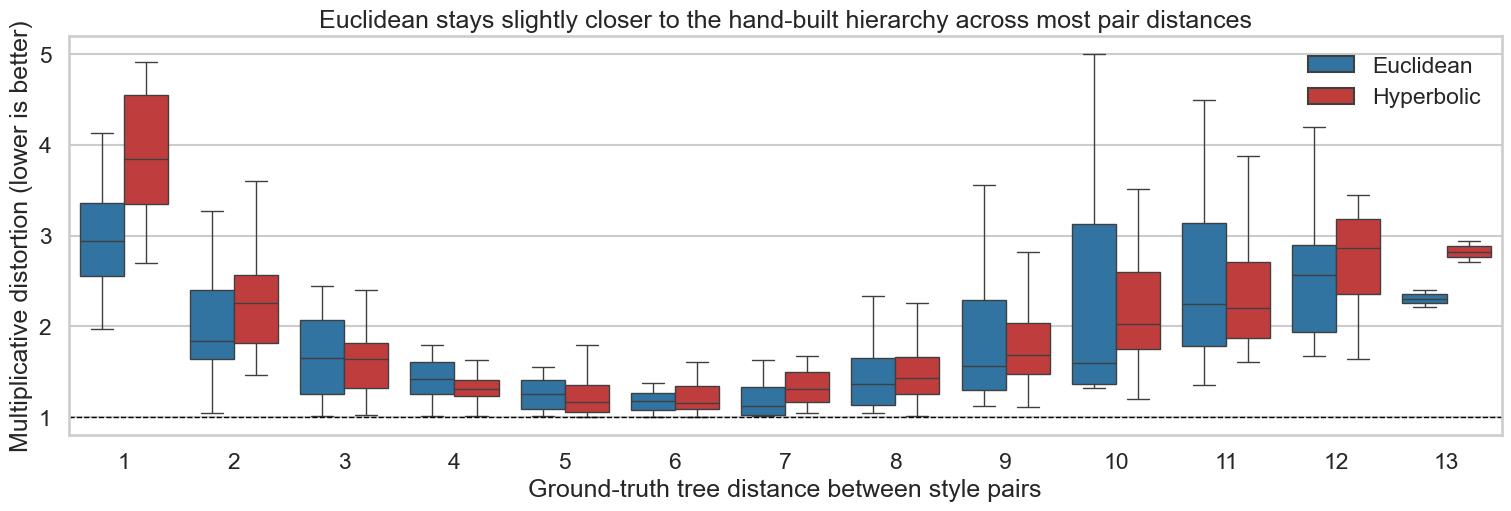

In [3]:
distortion_frames = []
for model, path in runs.items():
    df = pd.read_csv(path / 'tree_distortion_pairs.csv')
    df['model'] = model
    distortion_frames.append(df)
distortion_df = pd.concat(distortion_frames, ignore_index=True)
distortion_df['tree_distance'] = distortion_df['tree_distance'].astype(int)

fig, ax = plt.subplots(figsize=(15, 5), constrained_layout=True)
sns.boxplot(
    data=distortion_df,
    x='tree_distance',
    y='multiplicative_distortion',
    hue='model',
    palette=colors,
    showfliers=False,
    ax=ax,
)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Ground-truth tree distance between style pairs')
ax.set_ylabel('Multiplicative distortion (lower is better)')
ax.set_title('Euclidean stays slightly closer to the hand-built hierarchy across most pair distances')
ax.legend(title='', frameon=False)
plt.show()


#### Question 3. Are The Gains And Losses Broad Or Style-Specific?

Source: `per_class_accuracy.csv`. Positive bars mean the hyperbolic model does better for that style; negative bars mean the Euclidean baseline does better. This lets us check whether the aggregate result is broad or driven by only a few classes.

Most styles fall on the Euclidean side of zero, so the overall Euclidean advantage is fairly broad rather than coming from just one dominant class. Hyperbolic does pick up a few local wins, but those gains are too narrow to offset the larger number of styles where Euclidean performs better.


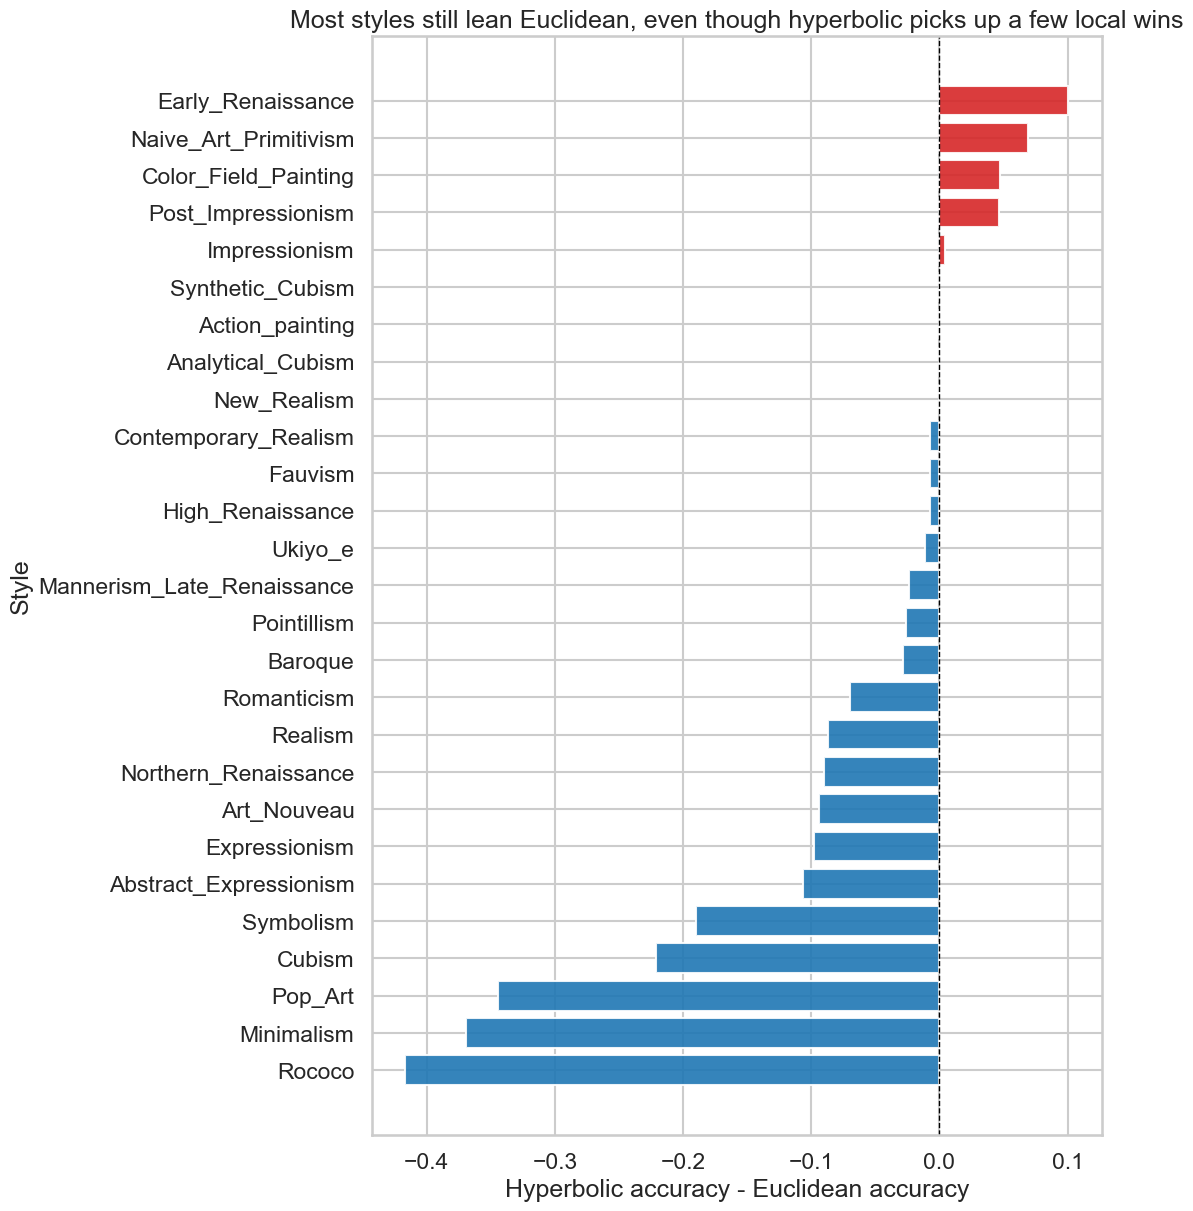

In [4]:
eu = pd.read_csv(runs['Euclidean'] / 'per_class_accuracy.csv')[['style', 'accuracy', 'num_examples']]
hy = pd.read_csv(runs['Hyperbolic'] / 'per_class_accuracy.csv')[['style', 'accuracy']]
per_class = eu.merge(hy, on='style', suffixes=('_euclidean', '_hyperbolic'))
per_class['delta'] = per_class['accuracy_hyperbolic'] - per_class['accuracy_euclidean']
per_class = per_class.sort_values('delta')

fig, ax = plt.subplots(figsize=(11, 12), constrained_layout=True)
bar_colors = [colors['Hyperbolic'] if value > 0 else colors['Euclidean'] for value in per_class['delta']]
ax.barh(per_class['style'], per_class['delta'], color=bar_colors, alpha=0.9)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Hyperbolic accuracy - Euclidean accuracy')
ax.set_ylabel('Style')
ax.set_title('Most styles still lean Euclidean, even though hyperbolic picks up a few local wins')
plt.show()


#### Question 4. Is Interpolation Stable For A Fine-Grained Family Like Cubism?

Source: `frechet_interpolation_trials.csv`. Lower distances are better in the first and third panels, while a larger positive margin is better in the middle panel. This is the most direct picture of whether averaging several Cubism embeddings still produces something that behaves like Cubism.

Euclidean interpolation is much more stable: averaged Cubism embeddings stay closer to the Cubism prototype and to held-out Cubism samples, and they keep a clearer positive margin over other prototypes. The hyperbolic averages are farther away and more likely to drift toward non-Cubism prototypes, which explains the lower Frechet stability score.


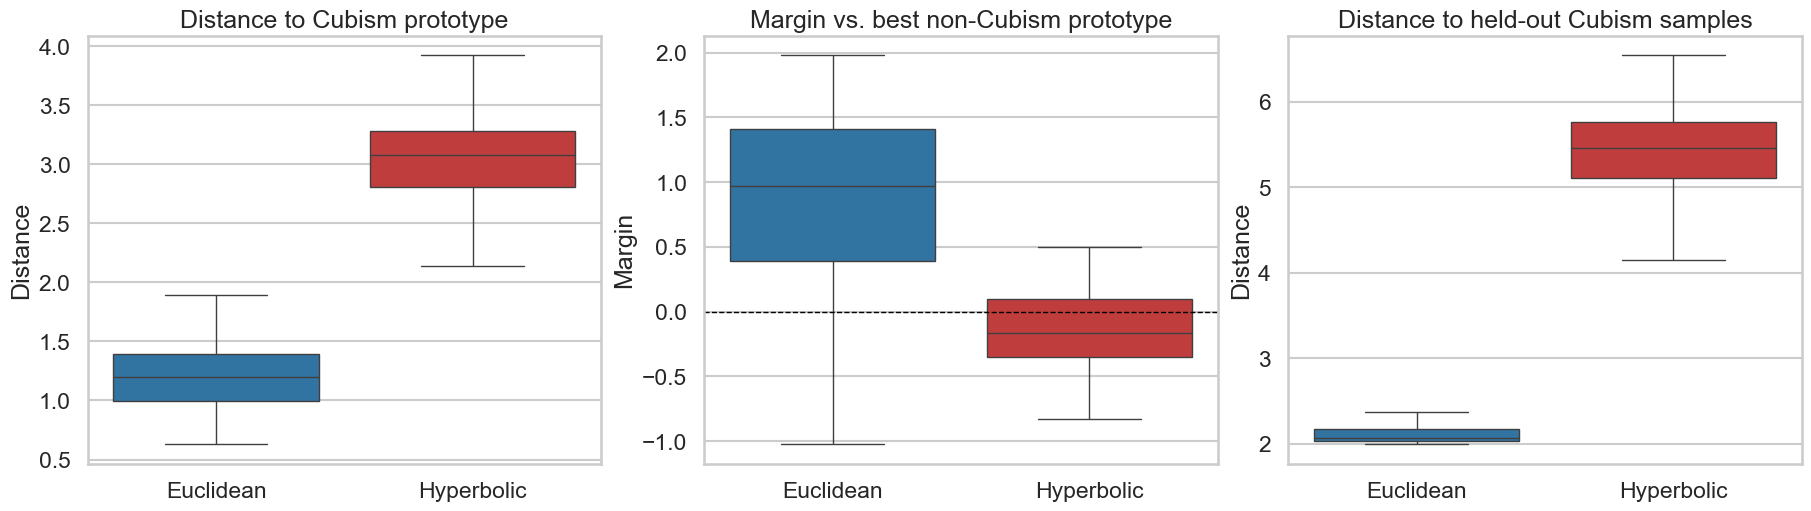

In [5]:
frechet_frames = []
for model, path in runs.items():
    df = pd.read_csv(path / 'frechet_interpolation_trials.csv')
    df['model'] = model
    frechet_frames.append(df)
frechet_df = pd.concat(frechet_frames, ignore_index=True)

plot_specs = [
    ('target_prototype_distance', 'Distance to Cubism prototype'),
    ('best_other_prototype_margin', 'Margin vs. best non-Cubism prototype'),
    ('mean_holdout_same_style_distance', 'Distance to held-out Cubism samples'),
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
for ax, (column, title) in zip(axes, plot_specs):
    sns.boxplot(
        data=frechet_df,
        x='model',
        y=column,
        hue='model',
        palette=colors,
        dodge=False,
        showfliers=False,
        ax=ax,
    )
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
    ax.set_title(title)
    ax.set_xlabel('')
    if column == 'best_other_prototype_margin':
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_ylabel('Distance')
axes[1].set_ylabel('Margin')
axes[2].set_ylabel('Distance')
plt.show()


#### Overall Read

Taken together, the plots support a fairly clear first conclusion. The **Euclidean baseline is stronger on the main global metrics and on Cubism interpolation stability**, so the current hyperbolic setup is not yet the better end-to-end model at `d=8` and 10 epochs. At the same time, the **hyperbolic model is not uniformly worse**. Its stronger sibling and cousin retrieval scores suggest that it may already be organizing local neighborhoods more effectively than the Euclidean baseline, even though that advantage has not yet translated into better global hierarchy recovery.

That makes the next experimental direction more concrete: if hyperbolic geometry is going to win, it will probably require either more training, different curvature or embedding dimension settings, or a loss that uses the hierarchy more directly than the current nearest-prototype objective.


## 5. Final Model Pipeline Setup:
Peter: Tune hyperbolic more fairly: more epochs, larger d, curvature sweep.

Luca: Add hierarchy-aware training, not just hierarchy-aware evaluation. Test different tree layouts. 

Valerie: Test robustness with multiple seeds and matched budgets. Explore class rebalancing, data augmentation. 

All: Inspect qualitative failures and nearest-neighbor examples.

Keeping Euclidean as a strong baseline throughout.